In [1]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../CSVs/08_model_ready_dataset.csv').drop(columns=['Unnamed: 0'])

In [3]:
# Changing columns names for more readability
df.columns = ['village_code', 'visit_month', 'spray_status', 'total_residents',
       'clinic_tests', 'total_rdts', 'avg_distance_to_health_facility_km',
       'incidence_per_1000', 'positivity_rate', 'dist_missing', 'rainfall',
       'rainfall_total', 'humidity', 'temp', 'max_temp', 'min_temp', 'temp_range',
       'prev_rainfall', 'prev2_rainfall', 'prev3_rainfall',
       'prev4_rainfall', 'prev_rainfall_total', 'prev2_rainfall_total',
       'prev3_rainfall_total', 'prev4_rainfall_total', 'prev_humidity',
       'prev2_humidity', 'prev3_humidity', 'prev4_humidity', 'prev_temp', 'prev2_temp',
       'prev3_temp', 'prev4_temp', 'prev_max_temp', 'prev2_max_temp',
       'prev3_max_temp', 'prev4_max_temp', 'prev_min_temp', 'prev2_min_temp',
       'prev3_min_temp', 'prev4_min_temp', 'prev_temp_range', 'prev2_temp_range',
       'prev3_temp_range', 'prev4_temp_range', 'prev_incidence_per_1000', 'mpi']

In [4]:
months = df['visit_month'].unique()
months.sort()

split_point = int(len(months) *.8) # This returns the index of the 80th percentile

In [5]:
# 80% / 20% chronological split
target_columns = ['incidence_per_1000', 'positivity_rate'] # These are the columns our model tries to predict
# And these are poor or useless columns that carry information about which villages have suffered epidemics before
# Causing it to overfit by predicting historical average
useless_columns = ['total_rdts', 'total_residents', 'visit_month', 'avg_distance_to_health_facility_km', 'village_code', 'clinic_tests']
# Train data becomes the majority (80%)
X_train = df[df['visit_month'] < months[split_point]]
y_train = X_train[target_columns]
# Test data becomes the minority (20%)
X_test = df[df['visit_month'] >= months[split_point]]
y_test = X_test[target_columns]
# We finally drop the target columns from the X data
X_train = X_train.drop(columns=target_columns + useless_columns) # We also don't need 'visit_month' anymore it isn't important in training
X_test = X_test.drop(columns=target_columns + useless_columns)

In [6]:
len(df['avg_distance_to_health_facility_km'].unique()) < len(df['village_code'].unique())
# This surely causes overfitting
# But I think it's supposed to be equal because I imputed some nans with medians and flagged them

True

In [7]:
linear = LinearRegression().fit(X_train, y_train)

In [8]:
mae = mean_absolute_error(y_test, linear.predict(X_test), multioutput='raw_values')
mae
# Linear Regression does have a fair accuracy. I didn't know it can perform this well. I am actually impressed!
# Random Forest should be 10x better!

array([80.3333889,  0.2494501])

In [9]:
model = RandomForestRegressor().fit(X_train, y_train)

In [10]:
mae = r2_score(y_test, model.predict(X_test), multioutput='raw_values')
mae
# It's accuracy decreased 2x once I dropped the columns that caused it to overfit

array([0.62319314, 0.00076765])

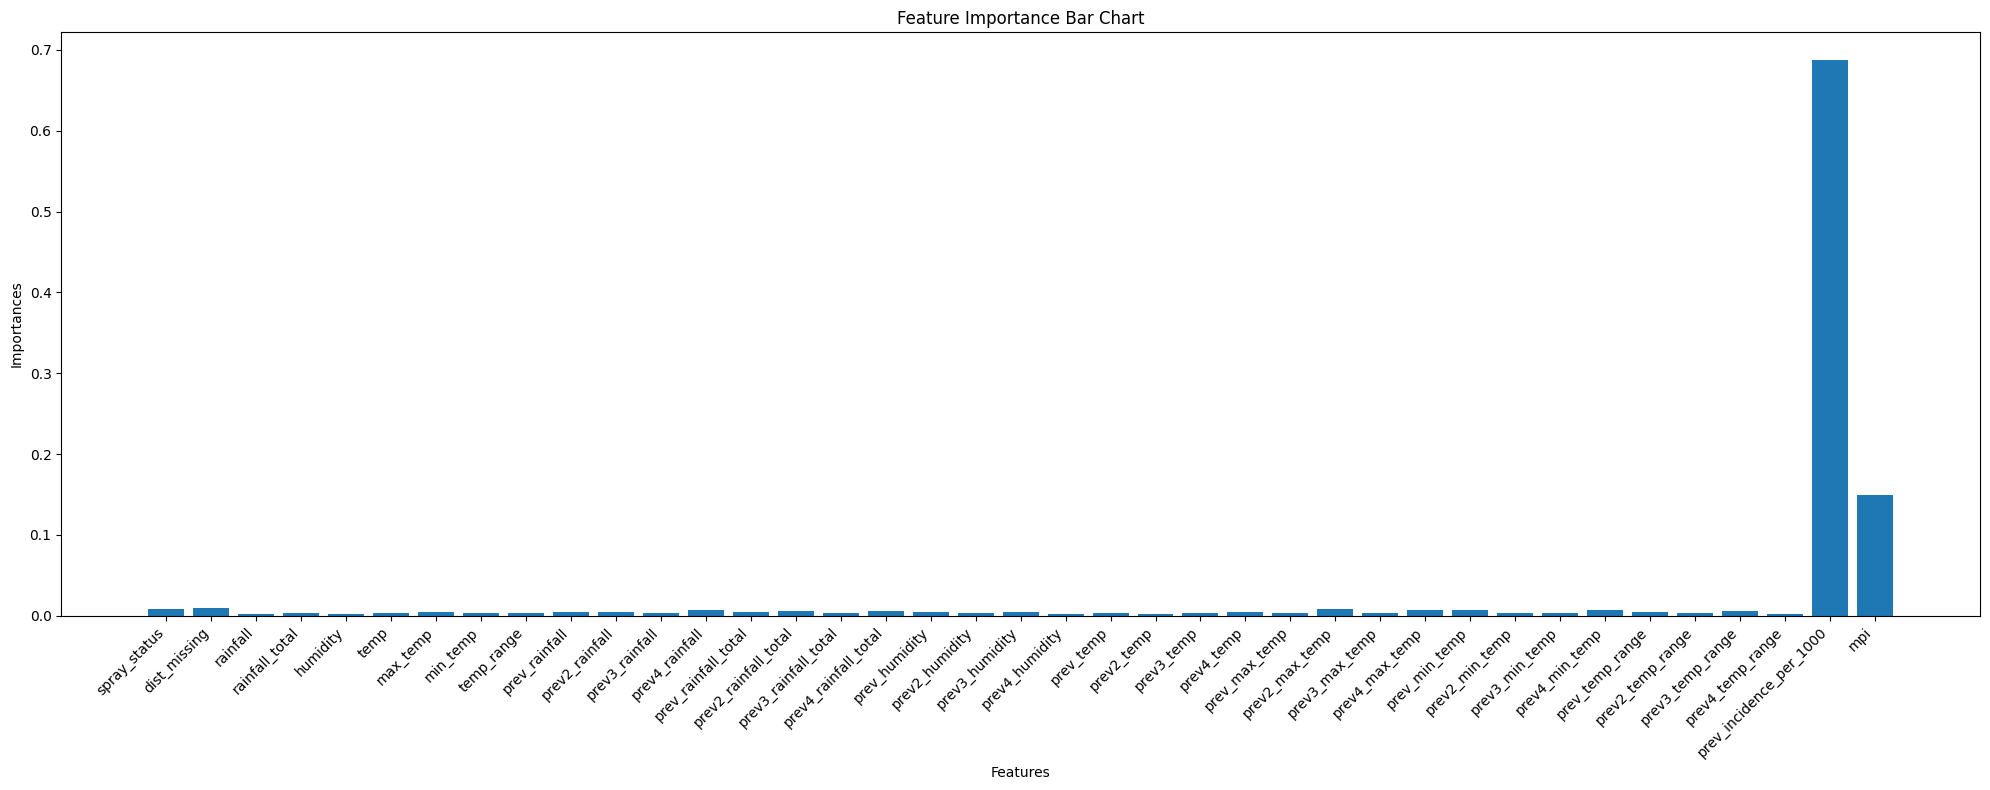

In [11]:
# Let's plot the feature importance and HOPE it's not overfitting
importances = model.feature_importances_
plt.figure(figsize=(20, 8))
plt.bar(X_test.columns, importances)
plt.xlabel('Features'); plt.ylabel('Importances')
plt.title('Feature Importance Bar Chart')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [12]:
y_test['incidence_per_1000'].describe()

count    862.000000
mean      83.681601
std      113.364072
min        0.000000
25%       16.840000
50%       44.625000
75%      106.662500
max      987.650000
Name: incidence_per_1000, dtype: float64

In [13]:
# Let's see if the random forest is shoots at outliers
outlier_sample = np.array(df.drop(columns=useless_columns + target_columns).mean().tolist()) * 100
model.predict(outlier_sample.reshape(1, -1))

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([[6.898829e+02, 5.991000e-01]])

In [14]:
model.predict(outlier_sample.reshape(1, -1))
# This seems to be the maximum it predicts

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([[6.898829e+02, 5.991000e-01]])

In [15]:
df['positivity_rate'].describe()

count    3726.000000
mean        0.607987
std         0.200117
min         0.000000
25%         0.500000
50%         0.610000
75%         0.740000
max         1.000000
Name: positivity_rate, dtype: float64

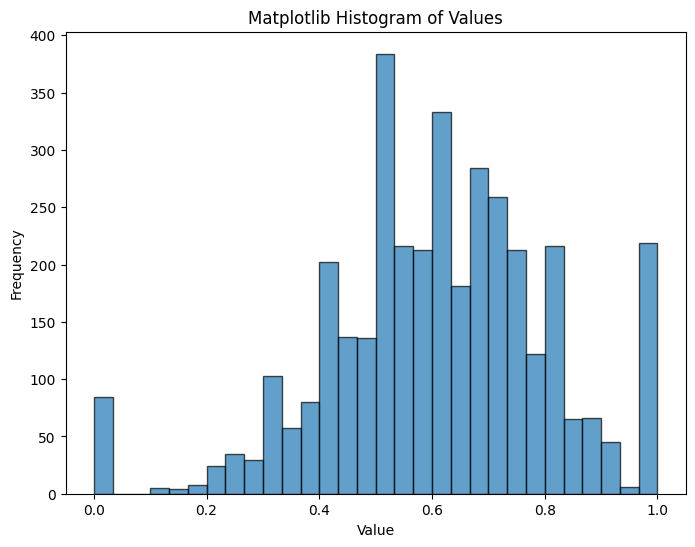

In [16]:
# --- Plot 1: Matplotlib Histogram ---
# Create the histogram to visualize the distribution of the 'values' column
plt.figure(figsize=(8, 6))
plt.hist(df['positivity_rate'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Matplotlib Histogram of Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [17]:
df['positivity_rate']

0       0.74
1       0.72
2       0.67
3       0.76
4       0.89
        ... 
3721    0.49
3722    1.00
3723    1.00
3724    1.00
3725    0.00
Name: positivity_rate, Length: 3726, dtype: float64

In [18]:
np.sum((linear.coef_ > 0).astype(int), axis=1)
print((linear.coef_ > 0).astype(int))

[[1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0
  1 1 1]
 [1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 1
  1 0 1]]


In [19]:
X_train.columns

Index(['spray_status', 'dist_missing', 'rainfall', 'rainfall_total',
       'humidity', 'temp', 'max_temp', 'min_temp', 'temp_range',
       'prev_rainfall', 'prev2_rainfall', 'prev3_rainfall', 'prev4_rainfall',
       'prev_rainfall_total', 'prev2_rainfall_total', 'prev3_rainfall_total',
       'prev4_rainfall_total', 'prev_humidity', 'prev2_humidity',
       'prev3_humidity', 'prev4_humidity', 'prev_temp', 'prev2_temp',
       'prev3_temp', 'prev4_temp', 'prev_max_temp', 'prev2_max_temp',
       'prev3_max_temp', 'prev4_max_temp', 'prev_min_temp', 'prev2_min_temp',
       'prev3_min_temp', 'prev4_min_temp', 'prev_temp_range',
       'prev2_temp_range', 'prev3_temp_range', 'prev4_temp_range',
       'prev_incidence_per_1000', 'mpi'],
      dtype='object')

In [20]:
target_idx = 0  # choose which target
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'sign': np.sign(linear.coef_[target_idx])
})
coefs

,feature,sign
0,spray_status,1.0
1,dist_missing,-1.0
2,rainfall,-1.0
3,rainfall_total,1.0
4,humidity,1.0
5,temp,-1.0
6,max_temp,1.0
7,min_temp,-1.0
8,temp_range,-1.0
9,prev_rainfall,-1.0
